## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [4]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [21]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

# %  di teste / lanci totali

In [ ]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)


In [30]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[]
for n in campioni:
    ris=simulazione_lanci(n)
    risultati_campioni.append(ris)

ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


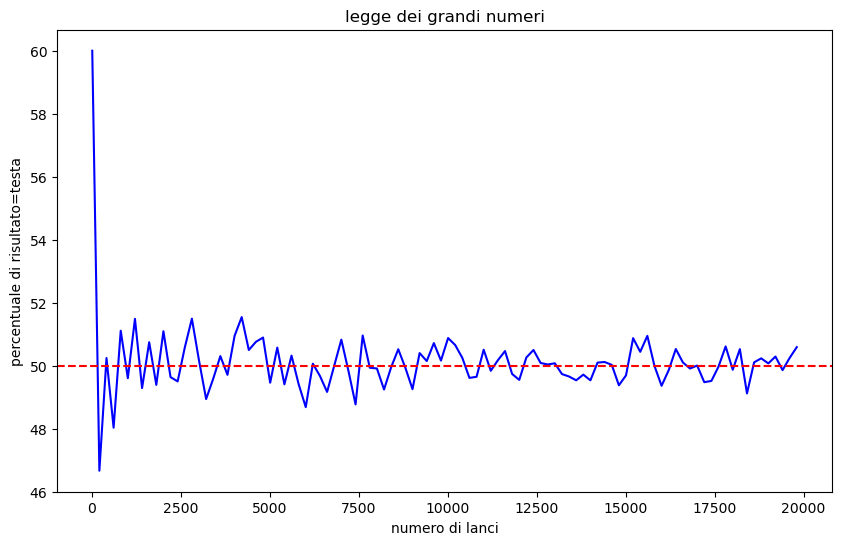

In [31]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

Numero righe e colonne: (891, 12)
Numero di NaN:  PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Numero di NaN:  PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64
Non ci sono righe duplicate
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


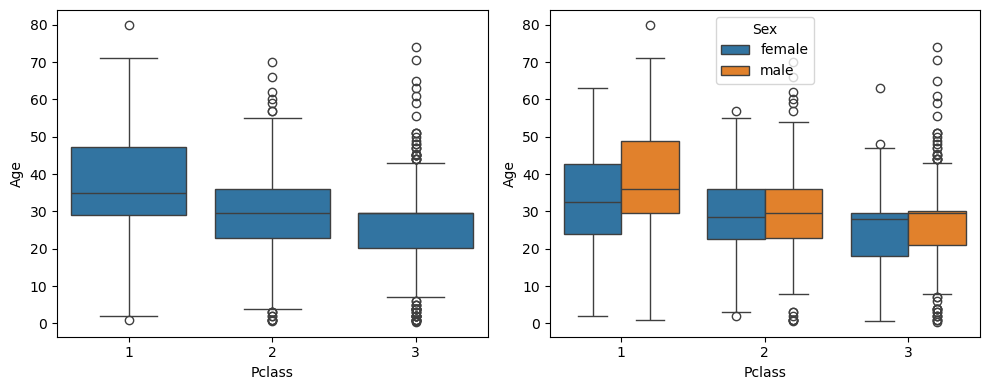

In [ ]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Numero righe e colonne:",df.shape)

moda=df["Embarked"].mode()[0]
print("Numero di NaN: ", df.isna().sum())
df["Embarked"]=df["Embarked"].fillna(moda)
print("Numero di NaN: " , df.isna().sum())


if(df.duplicated().any()==True):
    print("Ci sono righe duplicate:", df.duplicated().sum())
else:
    print("Non ci sono righe duplicate")

#prima calcolo la media tra i gruppi dei passeggeri, poi sostituisco il valore medio (di tutti) agli na
print(df.groupby("Pclass")["Age"].mean())
df["Age"]=df["Age"].fillna(df["Age"].mean())

f, grafici = plt.subplots(1,2,figsize=(10,4))

sns.boxplot(data= df,x="Pclass",y="Age", ax=grafici[0])
sns.boxplot(data= df,x="Pclass",y="Age", hue="Sex",ax=grafici[1])
plt.tight_layout()
plt.show()


## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

df["species"].value_counts()

df.head()
print(df.groupby("species")[["petal_length","petal_width"]].mean())

            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


Text(0.5, 1.0, 'Dimensioni petali')

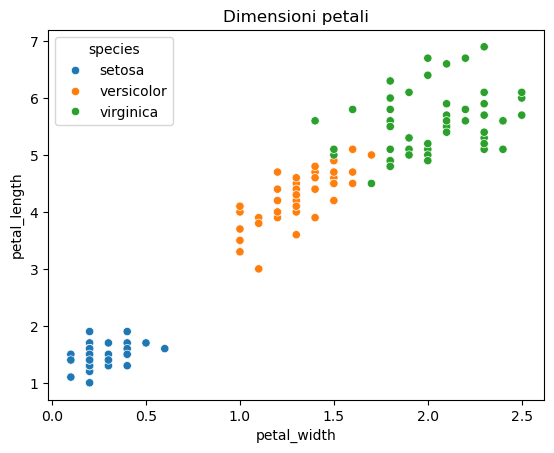

In [ ]:
sns.scatterplot(x=df["petal_width"], y=df["petal_length"], hue=df["species"])
plt.title("Dimensioni petali")

In [189]:
df["petal_area"] = df["petal_length"]*df["petal_width"]
print("\nArea media per specie:\n", df.groupby("species")["petal_area"].mean())


Area media per specie:
 species
setosa         0.3656
versicolor     5.7204
virginica     11.2962
Name: petal_area, dtype: float64


<Axes: xlabel='species', ylabel='petal_area'>

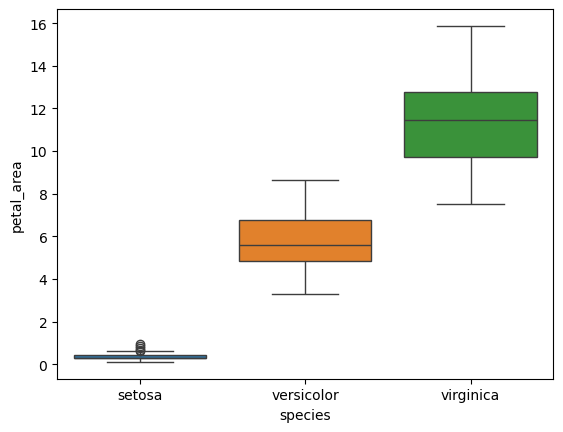

In [198]:
sns.boxplot(y=df["petal_area"],hue=df["species"], x=df["species"])